In [1]:
import sys
import os
import torch
sys.path.append(os.path.abspath('../'))

from src.models.single_network import SingleNetwork
from src.models.mc_dropout import MCDropout
from src.models.deep_ensemble import DeepEnsemble
from src.training.trainer import ModelTrainer
from src.processing.preprocess import get_dataloaders_for_sipakmed, getdataframe_for_sipakmed
from src.processing.loading import load_image_folder
from src.utils.visualisation import plot_performance_curves, plot_metrics_performance, ReliabilityPlotter
import pandas as pd
import matplotlib.pyplot as plt


`{im_Dyskeratotic: 0, im_Koilocytic: 1, im_Metaplasticimage_path: 2, im_Parabasal:3, im_Superficial-Intermediate: 4}`

In [2]:
train_loader, val_loader, cal_loader, test_loader = get_dataloaders_for_sipakmed(batch_size=32, num_workers=4, model_type="resnet")


df_all = getdataframe_for_sipakmed(train_loader, val_loader, cal_loader, test_loader)
df_all

,subset,image_path,label
0,train,/home/conite/Documents/STAGE/HybridUncertainty...,1
1,train,/home/conite/Documents/STAGE/HybridUncertainty...,0
2,train,/home/conite/Documents/STAGE/HybridUncertainty...,4
3,train,/home/conite/Documents/STAGE/HybridUncertainty...,0
4,train,/home/conite/Documents/STAGE/HybridUncertainty...,4
...,...,...,...
4044,test,/home/conite/Documents/STAGE/HybridUncertainty...,2
4045,test,/home/conite/Documents/STAGE/HybridUncertainty...,4
4046,test,/home/conite/Documents/STAGE/HybridUncertainty...,2
4047,test,/home/conite/Documents/STAGE/HybridUncertainty...,3


In [3]:
single_net = SingleNetwork(
    num_classes=5,
    learning_rate=5e-4,
    patience=5,
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    train_loader=train_loader,
    val_loader=val_loader,
    cal_loader=cal_loader,
    test_loader=test_loader,
    
)

mcdropout = MCDropout(
    num_classes=5,
    learning_rate=5e-4,
    patience=5,
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    train_loader=train_loader,
    val_loader=val_loader,
    cal_loader=cal_loader,
    test_loader=test_loader,
    
)

deepensemble = DeepEnsemble(
    num_classes=5,
    learning_rate=5e-4,
    patience=5,
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    train_loader=train_loader,
    val_loader=val_loader,
    cal_loader=cal_loader,
    test_loader=test_loader,
    
)


/home/conite/anaconda3/envs/GPU_ENV/lib/python3.9/site-packages/torch/cuda/__init__.py:128: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /opt/conda/conda-bld/pytorch_1724789115370/work/c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0
/home/conite/anaconda3/envs/GPU_ENV/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/conite/anaconda3/envs/GPU_ENV/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50

**1.0 Evaluation**

In [4]:
# single_net.train(epochs=50, model_path='single_net_resnet_sipakmed.pth')
single_net.load('../experiments/results/sipakmed/output_single_resnet50_sipakmed.pth')
results_sn = single_net.evaluate()
print(f"Accuracy: {results_sn['accuracy']} | F1: {results_sn['f1_score']} | Precision: {results_sn['precision']} | Recall: {results_sn['recall']} | Brier: {results_sn['brier_score']} ")

/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/src/models/base_model.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(pa

Accuracy: 0.9720394736842105 | F1: 0.9720882585113793 | Precision: 0.9725019582066006 | Recall: 0.9720394736842105 | Brier: 0.044523559510707855 


In [5]:
mcdropout.load('../experiments/results/sipakmed/output_mcdropout_resnet50_sipakmed.pth')
results_mcd = mcdropout.evaluate()
print(f"Accuracy: {results_mcd['accuracy']} | F1: {results_mcd['f1_score']} | Precision: {results_mcd['precision']} | Recall: {results_mcd['recall']} | Brier: {results_mcd['brier_score']} ")

/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/src/models/base_model.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(pa

Accuracy: 0.9720394736842105 | F1: 0.9720882585113793 | Precision: 0.9725019582066006 | Recall: 0.9720394736842105 | Brier: 0.044523559510707855 


In [6]:
deepensemble.load([
    f"/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_deepensemble_resnet50_sipakmed_{i}.pth" for i in range(5)
])
results_de = deepensemble.evaluate()
print(f"Accuracy: {results_de['accuracy']} | F1: {results_de['f1_score']} | Precision: {results_de['precision']} | Recall: {results_de['recall']} | Brier: {results_de['brier_score']} ")


/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/src/models/deep_ensemble.py:116: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(model_path, map_location=

Model 1 loaded from /home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_deepensemble_resnet50_sipakmed_0.pth
Model 2 loaded from /home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_deepensemble_resnet50_sipakmed_1.pth
Model 3 loaded from /home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_deepensemble_resnet50_sipakmed_2.pth
Model 4 loaded from /home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_deepensemble_resnet50_sipakmed_3.pth
Model 5 loaded from /home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_deepensemble_resnet50_sipakmed_4.pth

🔎 Predicting with ensemble member 1/5



🔎 Predicting with ensemble member 2/5



🔎 Predicting with ensemble member 3/5



🔎 Predicting with ensemble member 4/5



🔎 Predicting with ensemble member 5/5


Accuracy: 0.9917763157894737 | F1: 0.9917693469346797 | Precision: 0.9917760834820101 | Recall: 0.9917763157894737 | Brier: 0.017302077263593674 


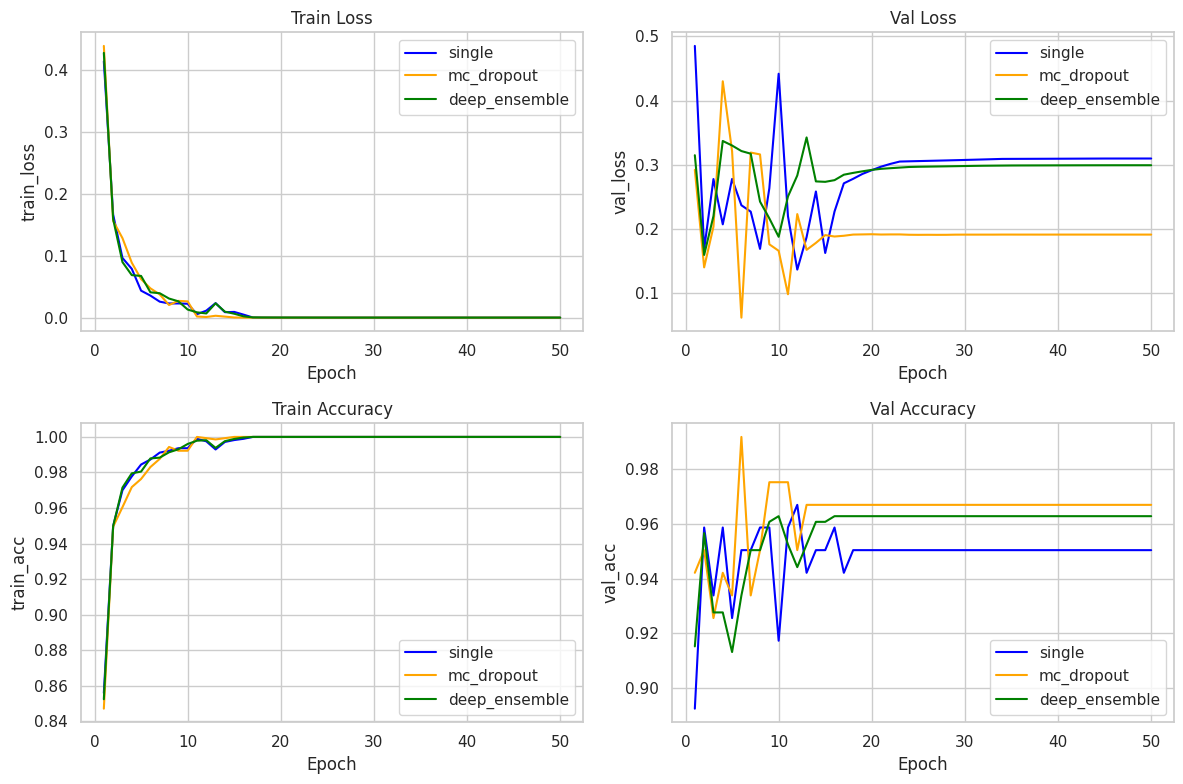

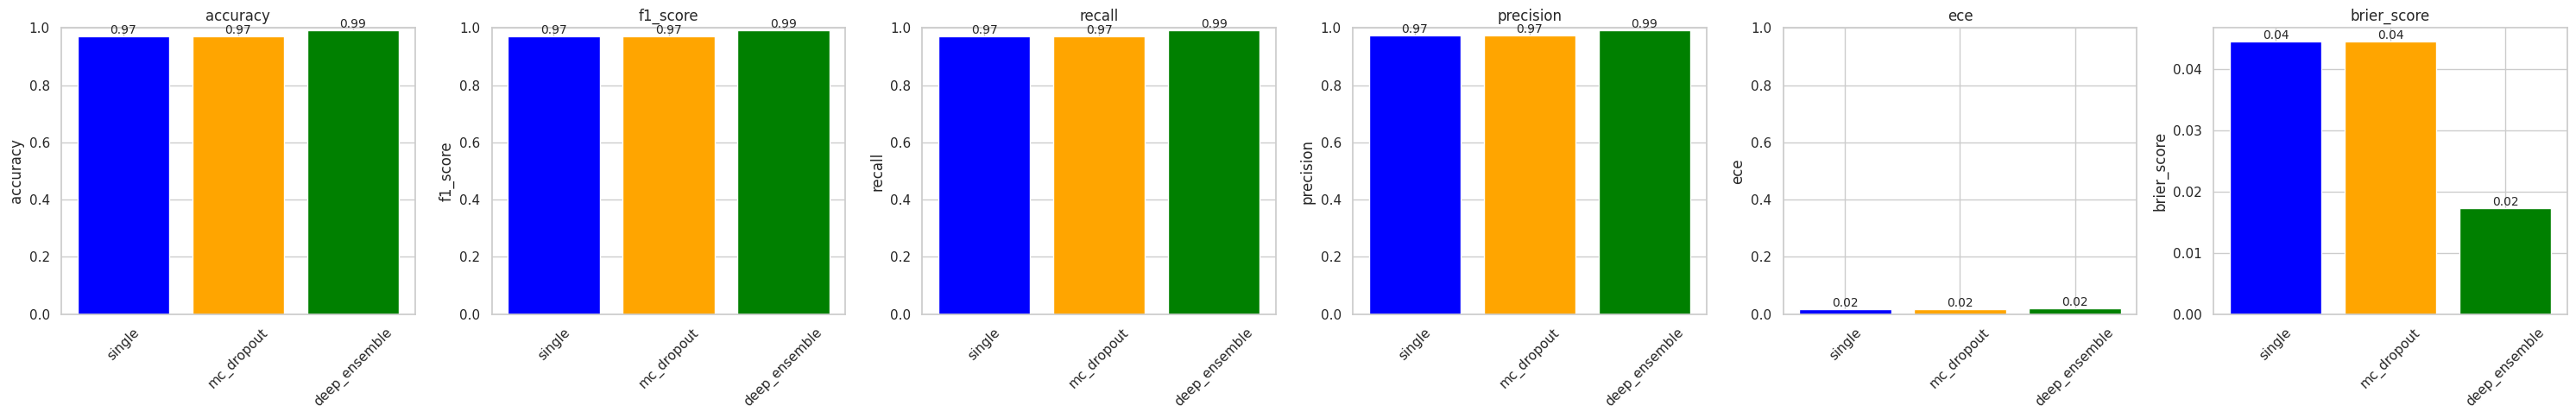

In [7]:
ENSEMBLE_SIZE = 5
path_results = {
    'single': os.path.join("/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_single_resnet50_sipakmed.json"),
    
    'mc_dropout': os.path.join("/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_mcdropout_resnet50_sipakmed.json"),
    'deep_ensemble': [
        os.path.join(f"/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_deepensemble_resnet50_sipakmed_{i}.json") 
        for i in range(1,ENSEMBLE_SIZE)
    ]
}

gather_results = {
    'single': results_sn,
    'mc_dropout': results_mcd,
    'deep_ensemble': results_de
}


plot_performance_curves(path_results=path_results)
plot_metrics_performance(gather_results)

**Step 2: Analyze each model's calibration performance (e.g., via ECE, Brier score), identifying which base approach is best calibrated across the three datasets**


Plotting reliability diagram for approach: single


<Figure size 600x500 with 0 Axes>

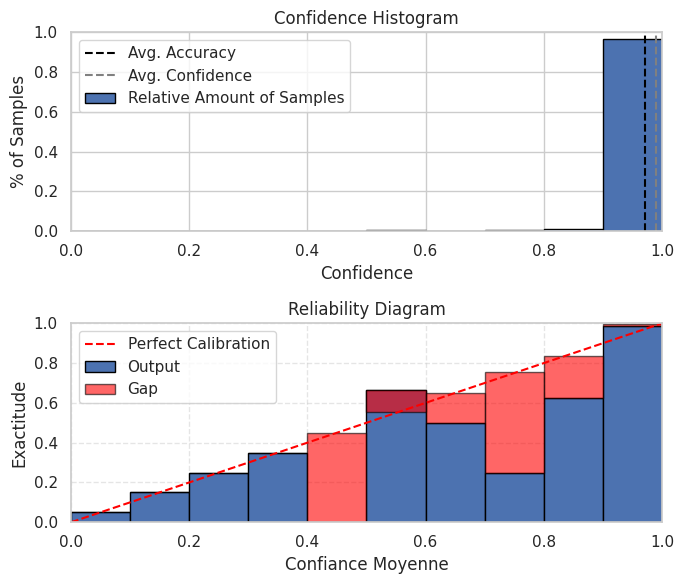

Plotting reliability diagram for approach: mc_dropout


<Figure size 600x500 with 0 Axes>

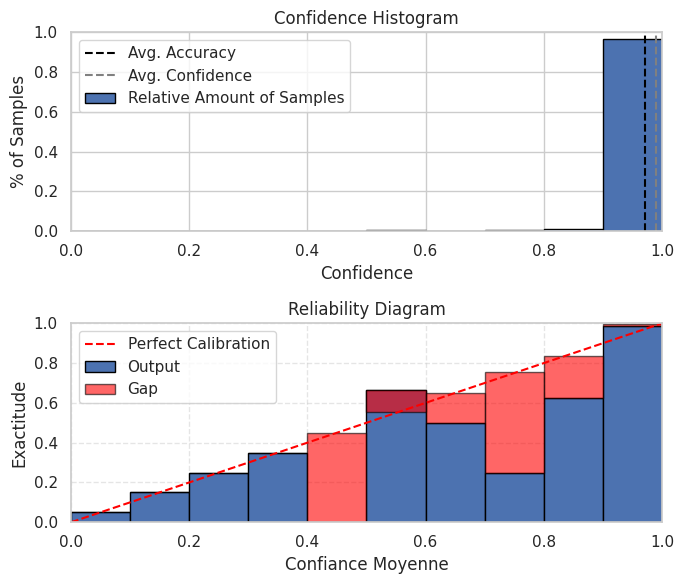

Plotting reliability diagram for approach: deep_ensemble


<Figure size 600x500 with 0 Axes>

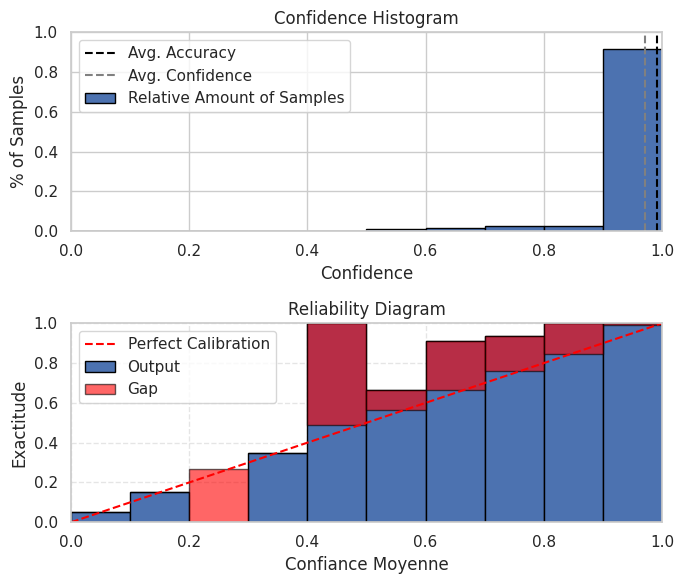

In [8]:
approaches_data = {
    'single': (results_sn['y_labels'], results_sn['y_probs']),
    'mc_dropout': (results_mcd['y_labels'], results_mcd['y_probs']),
    'deep_ensemble': (results_de['y_trues'], results_de['y_probs'])
}

plotter = ReliabilityPlotter(approaches_data)
plotter.plot_all_approaches(n_bins=10)

**Step 3: For each base method's (SingleNet, MCD, DE), apply APS, RAPS, and SAPS to create conformal sets, then compare their mean/median set sizes, marginal coverage, etc... and accuracy-per-set-size trade-offs to come out with the most efficient combinaison strategy on the three datasets.**

In [ ]:
from src.conformal_prediction.cp_old import ConformalPredictor

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


alpha = 0.05
predictors = {
    'APS': ConformalPredictor(method='aps', lambda_param=0, k_reg=0, randomize=True),
    'RAPS': ConformalPredictor(method='raps', lambda_param=10, k_reg=2, randomize=True),
    'SAPS': ConformalPredictor(method='saps', lambda_param=0.75, k_reg=2, randomize=True),
    'GAPS': ConformalPredictor(method='gaps', lambda_param=0.75, k_reg=2, randomize=True),
    'EAPS': ConformalPredictor(method='eaps', lambda_param=0.75, k_reg=2, randomize=True),
    'GEAPS': ConformalPredictor(method='geaps', lambda_param=0.75, k_reg=2, randomize=True),
}

for predictor_name, predictor in predictors.items():
    print(f"Calibrating {predictor_name}")
    cal_probs = results_sn['y_probs']
    cal_labels = results_sn['y_labels']
    cal_vars = results_sn['y_variances']    
    predictor.calibrate(cal_probs, cal_labels, cal_vars, alpha=alpha)
    print(f"Best tau: {predictor.tau}")


Calibrating APS
Best tau: 0.9616254526287625
Calibrating RAPS
[DEBUG] tau: 0.9563453402601183 | index: 578 | n: 608 | alpha: 0.05 | sorted_scores: [1.71763974e-04 2.34901943e-03 2.55384039e-03 2.58554671e-03
 2.72656889e-03 4.13581730e-03 5.85897712e-03 9.85643941e-03
 1.39967869e-02 1.83355952e-02 1.90748552e-02 1.91142647e-02
 1.91202360e-02 1.98376291e-02 2.06278877e-02 2.52384852e-02
 2.61894723e-02 2.86444122e-02 2.97658163e-02 3.04857903e-02
 3.27586593e-02 3.43979216e-02 3.70710206e-02 4.27768876e-02
 4.41103798e-02 4.43321115e-02 4.52434530e-02 4.56862971e-02
 4.78320955e-02 4.84937577e-02 4.90002846e-02 4.91228916e-02
 5.03127653e-02 5.21783070e-02 5.30668709e-02 5.62416484e-02
 5.70751249e-02 5.76261211e-02 6.36020394e-02 6.67536857e-02
 6.73974596e-02 6.81251126e-02 6.98449378e-02 6.98885301e-02
 7.05421019e-02 7.20421265e-02 7.38783220e-02 7.38952171e-02
 7.48136568e-02 7.50645463e-02 7.52649040e-02 7.64953074e-02
 7.71564571e-02 7.83890711e-02 7.92527596e-02 8.28270274e-02

 <======================Single approach======================>


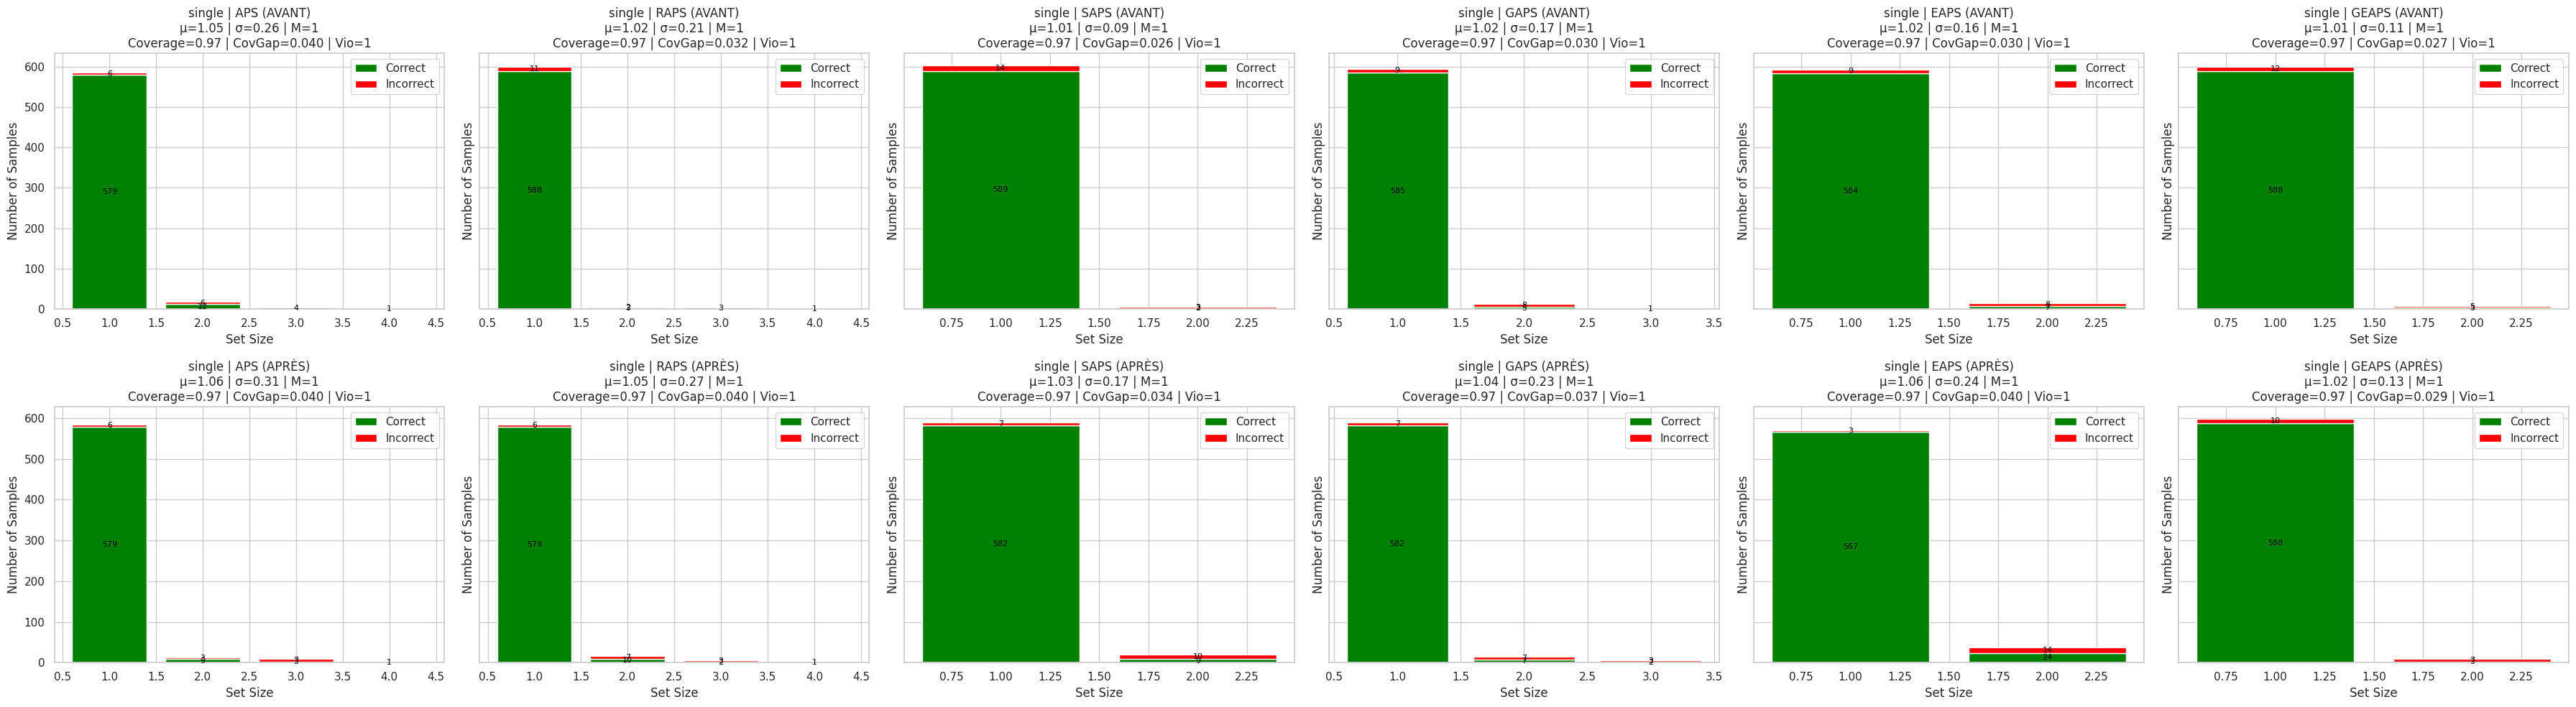

 <======================MCDropout approach======================>


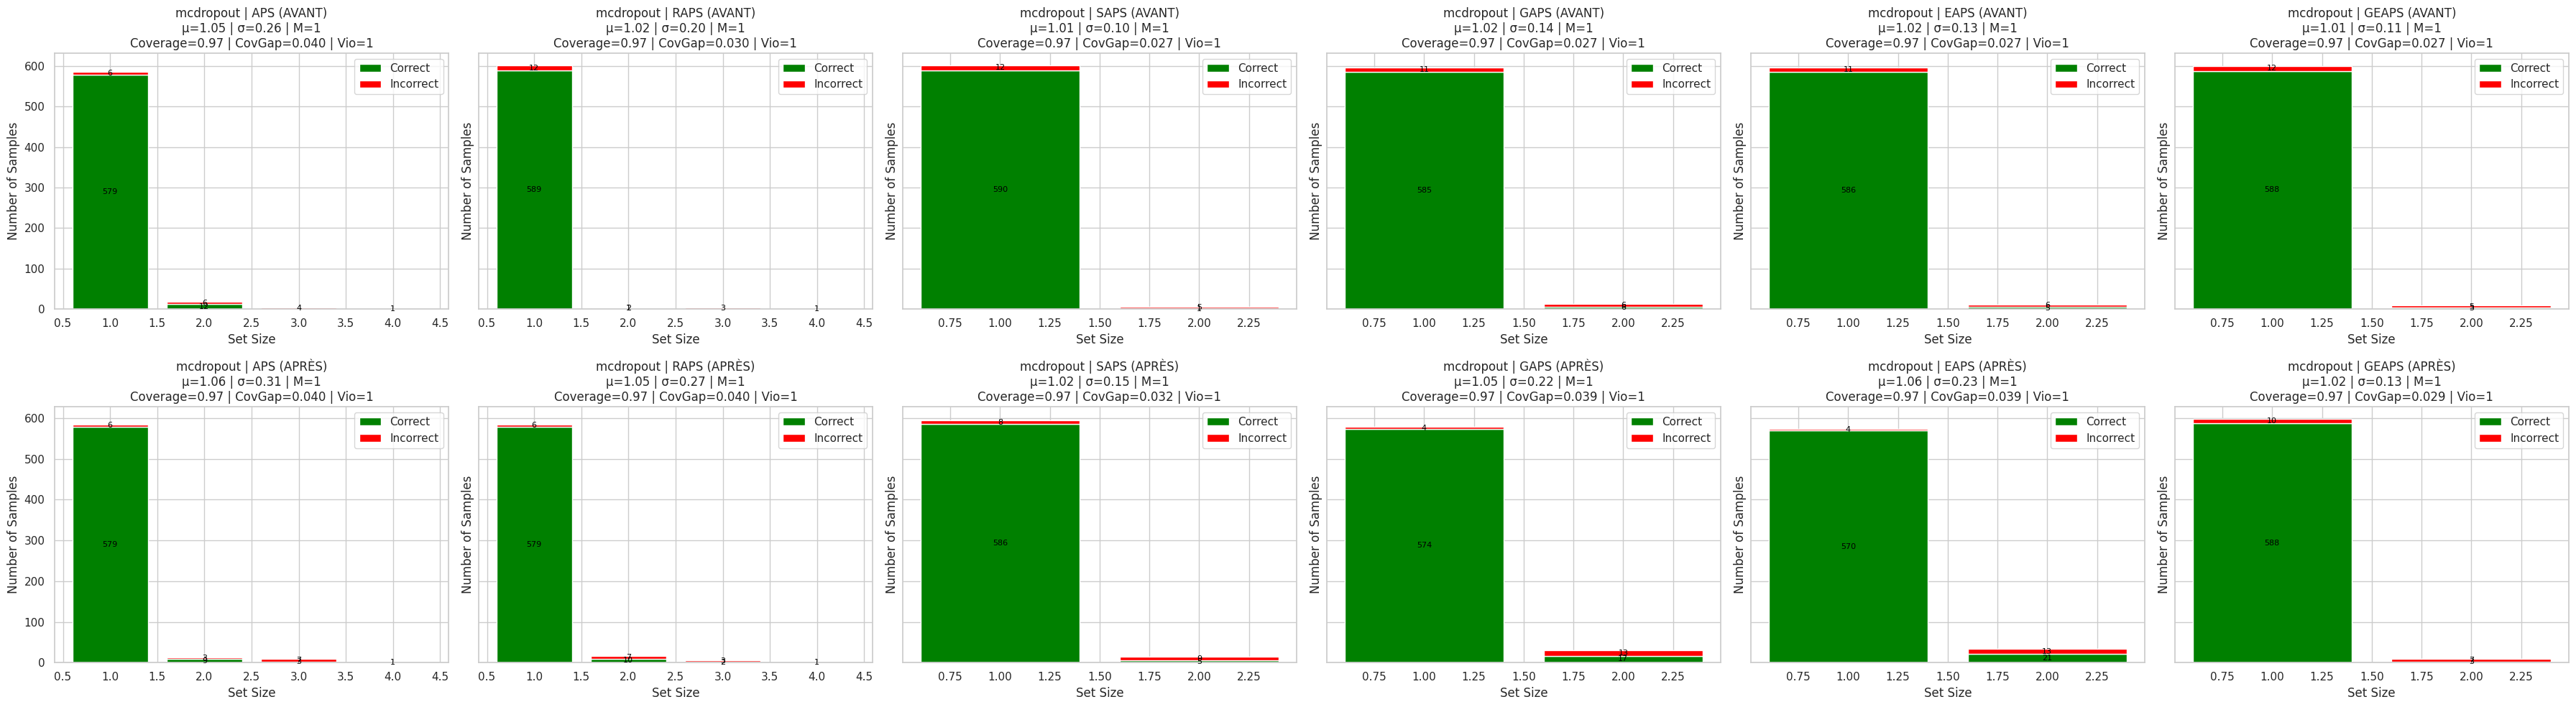

 <======================Deep Ensemble approach======================>


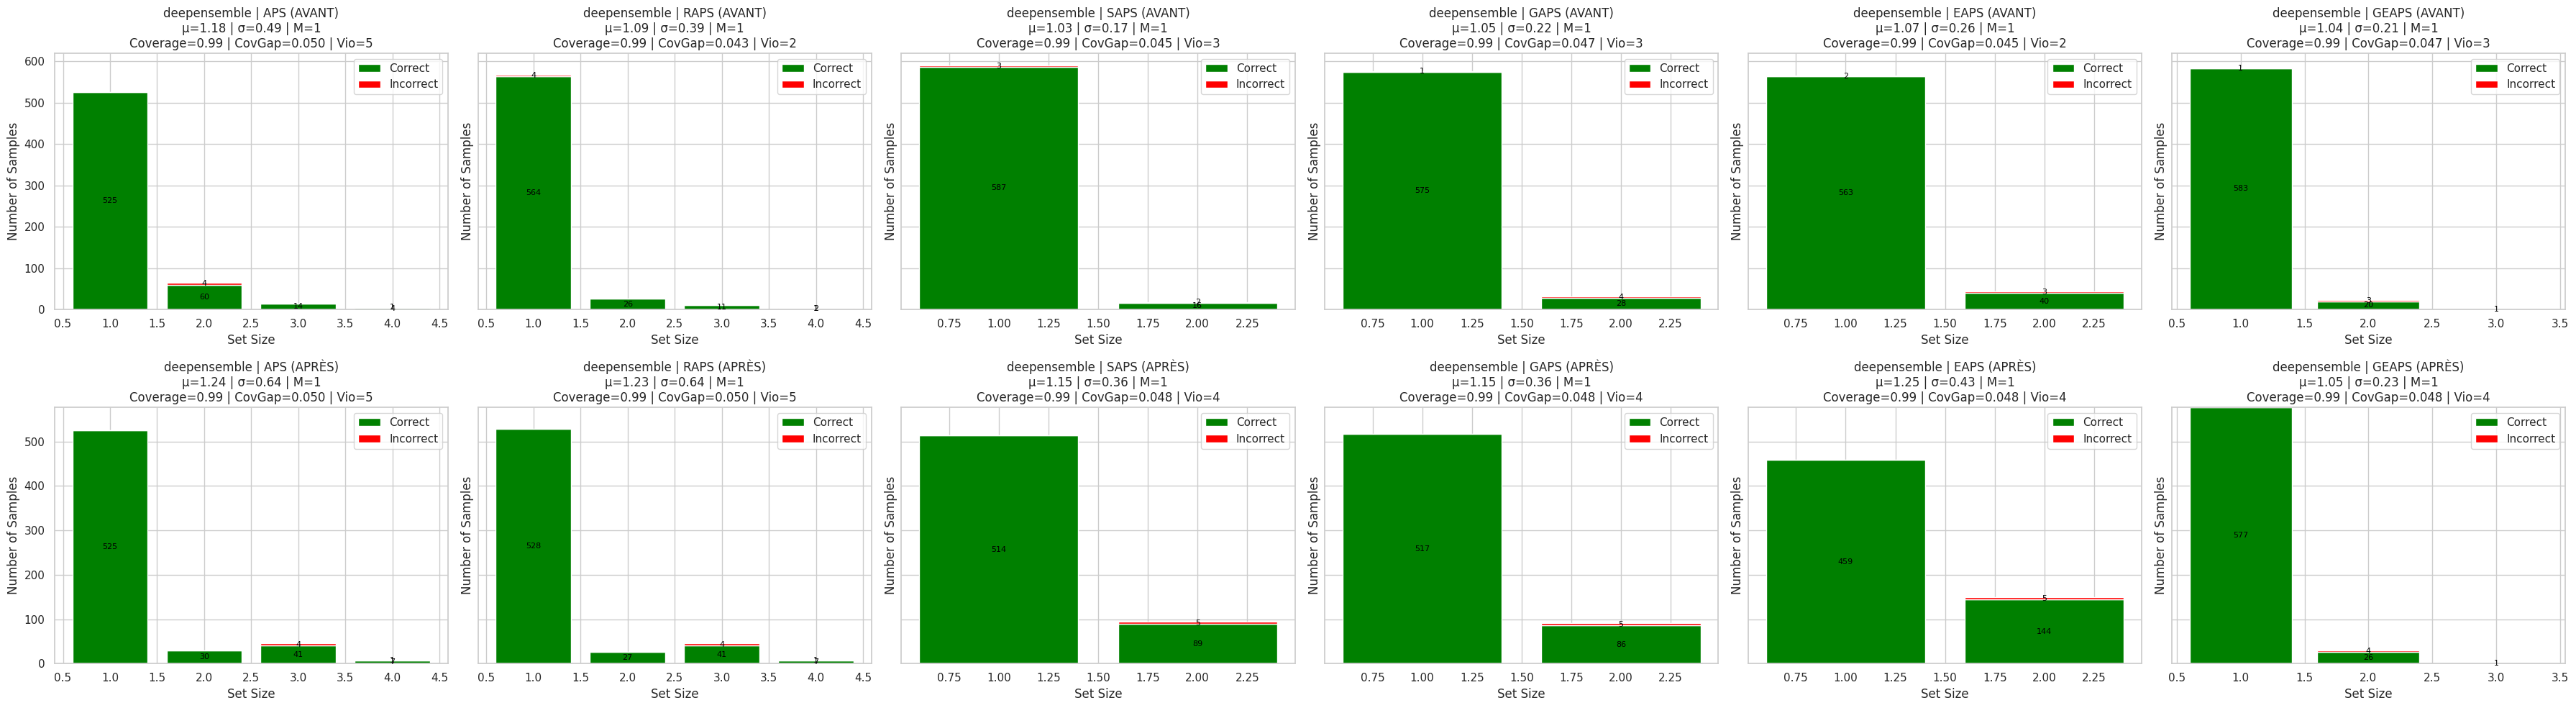

In [21]:
from src.utils.visualisation import plot_correct_incorrect_bars 

print(f" <======================Single approach======================>")
results_prediction_sn = plot_correct_incorrect_bars(
    predictors,
    test_probs=results_sn['y_probs'],
    y_test=results_sn['y_labels'],
    y_entropies=results_sn['entropy'],
    alpha=alpha,
    approach_name='single',
)

print(f" <======================MCDropout approach======================>")
results_prediction_mcd = plot_correct_incorrect_bars(
    predictors,
    test_probs=results_mcd['y_probs'],
    y_test=results_mcd['y_labels'],
    y_entropies=results_mcd['entropy'],
    alpha=alpha,
    approach_name='mcdropout',
)
print(f" <======================Deep Ensemble approach======================>") 
results_prediction__de = plot_correct_incorrect_bars(
    predictors,
    test_probs=results_de['y_probs'],
    y_test=results_de['y_trues'],
    y_entropies=results_de['entropy'],
    alpha=alpha,
    approach_name='deepensemble',
)

In [22]:
# get number of correctly predicted and misclassified samples with probas=results_sn['y_probs'], labels=results_sn['y_labels']
import numpy as np

def get_correctly_predicted_and_misclassified_samples(probas, labels):
    correctly_predicted = []
    misclassified = []
    predicted_classes = np.argmax(probas, axis=1)  # Get predicted classes from probabilities
    for i in range(len(predicted_classes)):
        if predicted_classes[i] == labels[i]:
            correctly_predicted.append(i)
        else:
            misclassified.append(i)
    return correctly_predicted, misclassified

correctly_predicted_sn, misclassified_sn = get_correctly_predicted_and_misclassified_samples(results_sn['y_probs'], results_sn['y_labels'])
print(f"Single Net | Number of correctly predicted samples: {len(correctly_predicted_sn)}")
print(f"Single Net | Number of misclassified samples: {len(misclassified_sn)}")

correctly_predicted_mcd, misclassified_mcd = get_correctly_predicted_and_misclassified_samples(results_mcd['y_probs'], results_mcd['y_labels'])
print(f"MC Dropout | Number of correctly predicted samples: {len(correctly_predicted_mcd)}")
print(f"MC Dropout | Number of misclassified samples: {len(misclassified_mcd)}")

correctly_predicted_de, misclassified_de = get_correctly_predicted_and_misclassified_samples(results_de['y_probs'], results_de['y_trues'])
print(f"Deep Ensemble | Number of correctly predicted samples: {len(correctly_predicted_de)}")
print(f"Deep Ensemble | Number of misclassified samples: {len(misclassified_de)}")

Single Net | Number of correctly predicted samples: 591
Single Net | Number of misclassified samples: 17
MC Dropout | Number of correctly predicted samples: 591
MC Dropout | Number of misclassified samples: 17
Deep Ensemble | Number of correctly predicted samples: 603
Deep Ensemble | Number of misclassified samples: 5


**4. Rejection Plot**

<======================single approach======================>
Cohen's d = -1.709
KS test statistic = 0.828, p-value = 6.74e-13


/home/conite/anaconda3/envs/GPU_ENV/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/conite/anaconda3/envs/GPU_ENV/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_2687198/1207998006.py:51: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(ents, shade=True, alpha=0.5, color=color, label=label, ax=ax_right)
/tmp/ipykernel_2687198/1207998006.py:51: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(ents, shade=True, alpha=0.5, color=color, label=label, ax=ax_right)


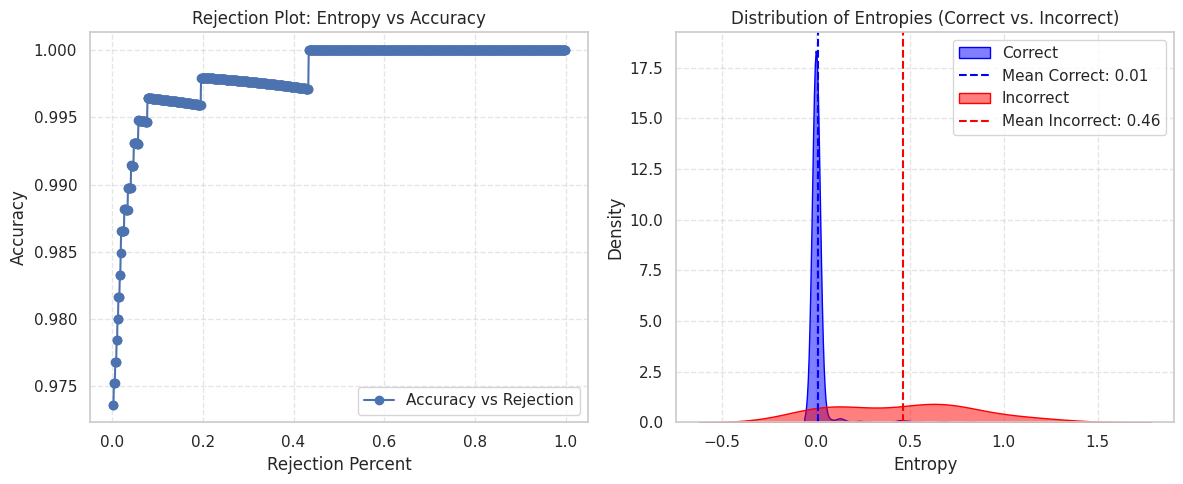

<======================mc_dropout approach======================>
Cohen's d = -1.709
KS test statistic = 0.828, p-value = 6.74e-13


/home/conite/anaconda3/envs/GPU_ENV/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/conite/anaconda3/envs/GPU_ENV/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_2687198/1207998006.py:51: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(ents, shade=True, alpha=0.5, color=color, label=label, ax=ax_right)
/tmp/ipykernel_2687198/1207998006.py:51: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(ents, shade=True, alpha=0.5, color=color, label=label, ax=ax_right)


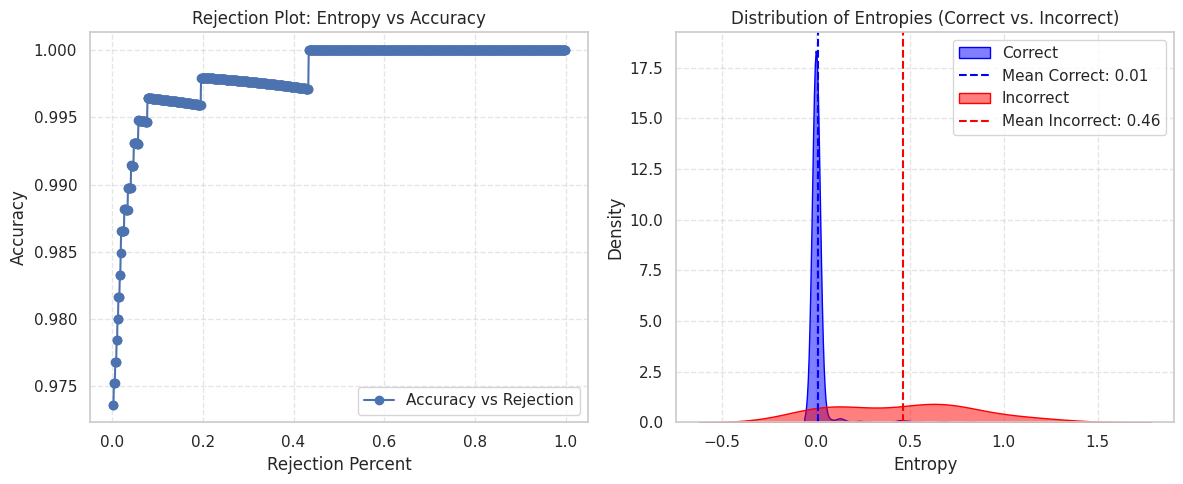

<======================deep_ensemble approach======================>
Cohen's d = -2.599
KS test statistic = 0.960, p-value = 3.49e-07


/home/conite/anaconda3/envs/GPU_ENV/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/conite/anaconda3/envs/GPU_ENV/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_2687198/1207998006.py:51: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(ents, shade=True, alpha=0.5, color=color, label=label, ax=ax_right)
/tmp/ipykernel_2687198/1207998006.py:51: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(ents, shade=True, alpha=0.5, color=color, label=label, ax=ax_right)


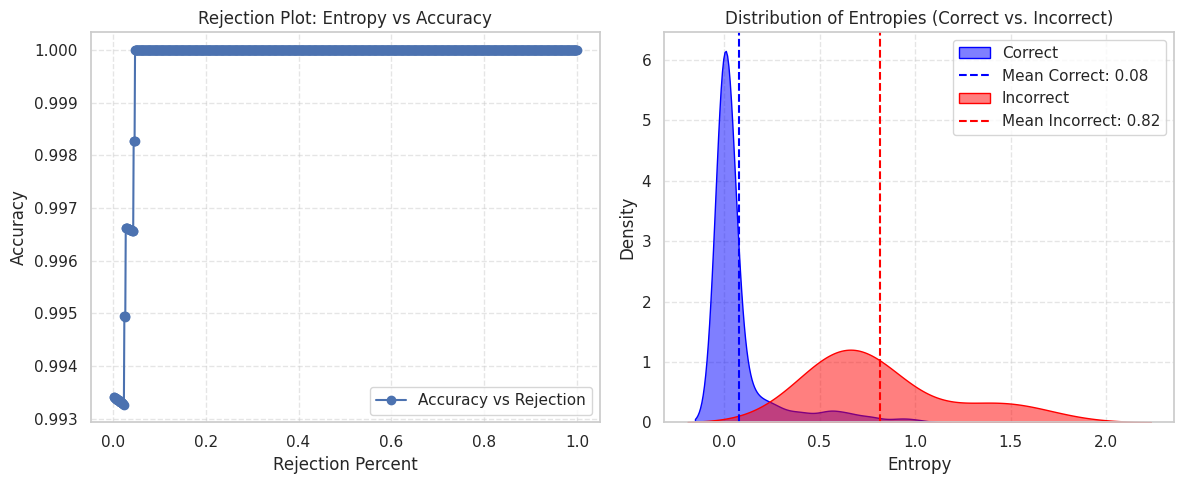

In [ ]:
from src.utils.visualisation import rejection_plot_with_kde_distribution

    

approaches_names = ['single', 'mc_dropout', 'deep_ensemble']
for approach in approaches_names:
    print(f"<======================{approach} approach======================>")
    rejection_plot_with_kde_distribution(
        test_probs=results_sn['y_probs'] if approach == 'single' else results_mcd['y_probs'] if approach == 'mc_dropout' else results_de['y_probs'],
        y_test=results_sn['y_labels'] if approach == 'single' else results_mcd['y_labels'] if approach == 'mc_dropout' else results_de['y_trues'],
        entropies=results_sn['entropy'] if approach == 'single' else results_mcd['entropy'] if approach == 'mc_dropout' else results_de['entropy'],
        num_points=1000,
    )


**4.1 Can we make Threshold dynamic ?**

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

def entropy_score(probs):
    return -np.sum(probs * np.log(probs + 1e-12), axis=1)

class DynamicThresholdMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.fc(x)

model_mlp = DynamicThresholdMLP()
optimizer = torch.optim.Adam(model_mlp.parameters(), lr=1e-3)
loss_fn = nn.BCELoss()


# ========== Single Network ==========

# Label = 1 si le score <= q̂, 0 sinon (on simule q̂ par percentile ici)
q_hat_ref = np.percentile(results_sn['entropy'], 1-alpha*100)
y_binary = (results_sn['entropy'] <= q_hat_ref).astype(float)
 
X_train = torch.tensor(results_sn['entropy'], dtype=torch.float32).unsqueeze(1)
y_binary = (results_sn['entropy'] <= q_hat_ref).astype(float)
y_train = torch.tensor(y_binary, dtype=torch.float32)
train_loader_ent = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)

for epoch in range(100):
    model_mlp.train()
    for x_batch, y_batch in train_loader_ent:
        preds = model_mlp(x_batch).squeeze()
        loss = loss_fn(preds, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")



In [ ]:
from src.utils.visualisation import analyze_entropy_vs_set_size_all_methods

 <======================Single approach======================>


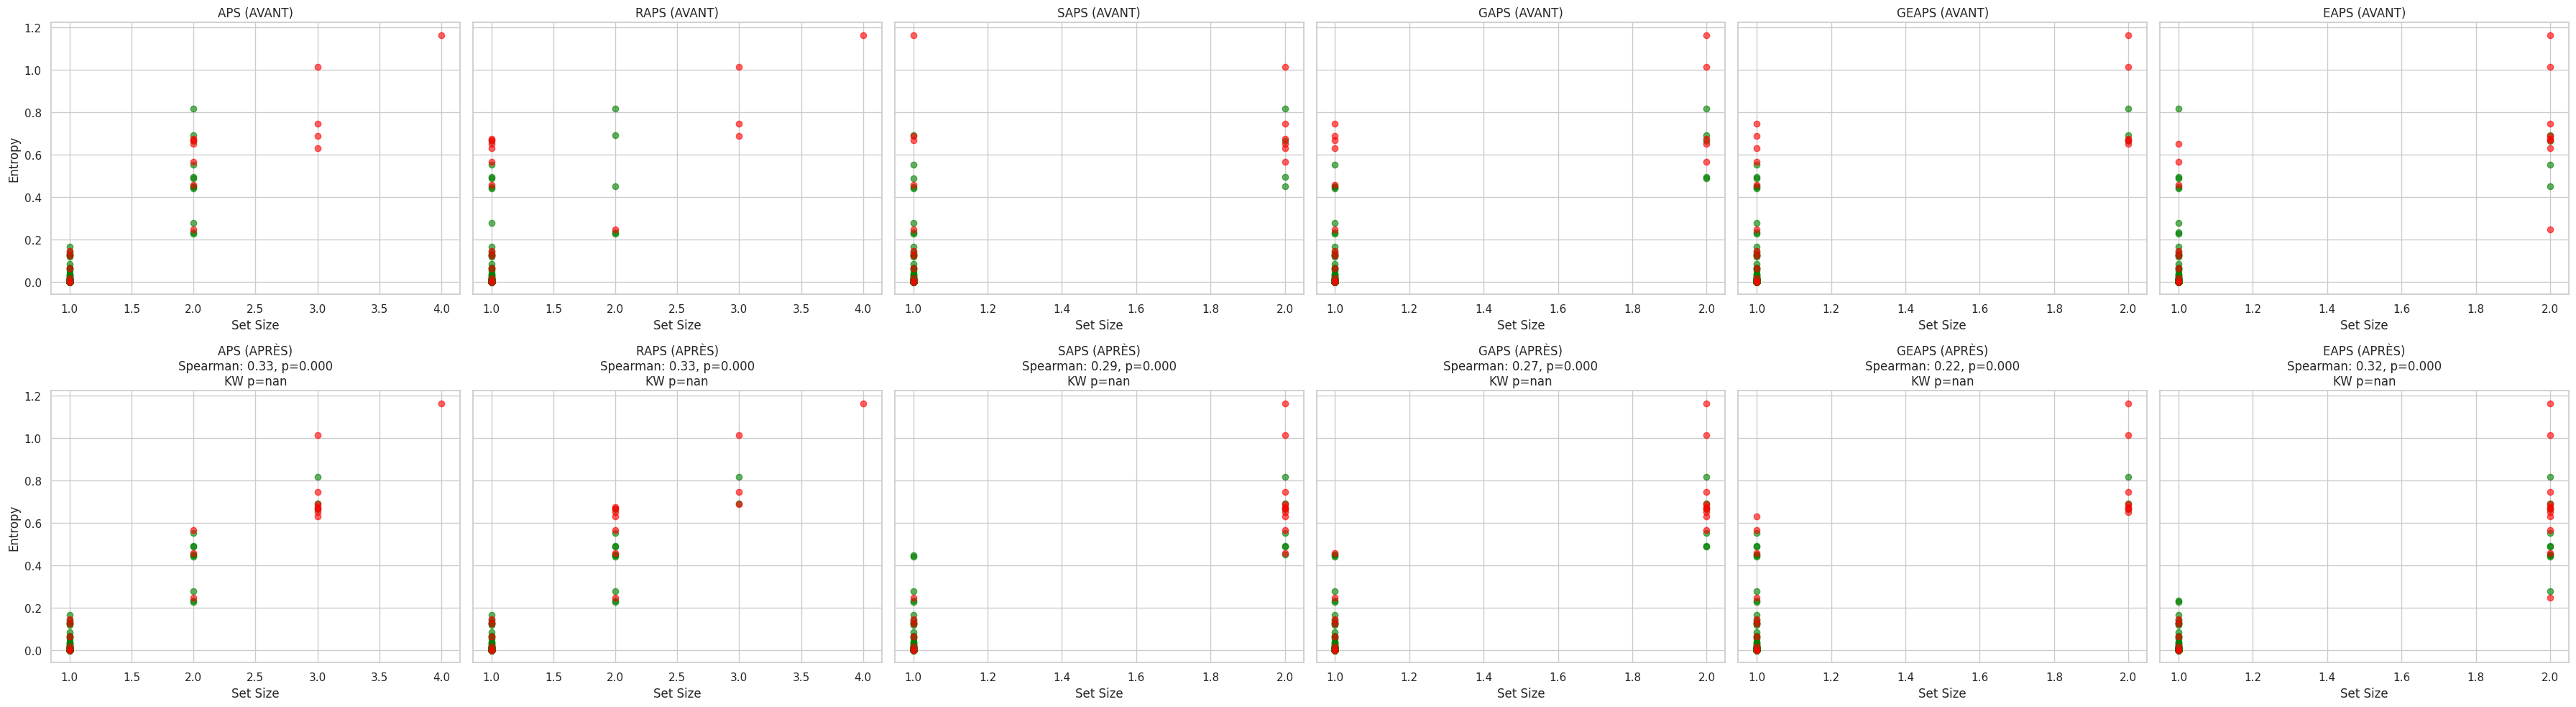

In [ ]:
predictor_dict = {
    'APS': predictors['APS'],
    'RAPS': predictors['RAPS'],
    'SAPS': predictors['SAPS'],
    'GAPS': predictors['GAPS'],
    'GEAPS': predictors['GEAPS'],
    'EAPS': predictors['EAPS'],
}

print(f" <======================Single approach======================>")
results_scatter_sn_ =  analyze_entropy_vs_set_size_all_methods(
    predictor_dict,
    test_probs=results_sn['y_probs'],
    y_test=results_sn['y_labels'],
    entropies=results_sn['entropy']
)


 <======================MCDropout approach======================>


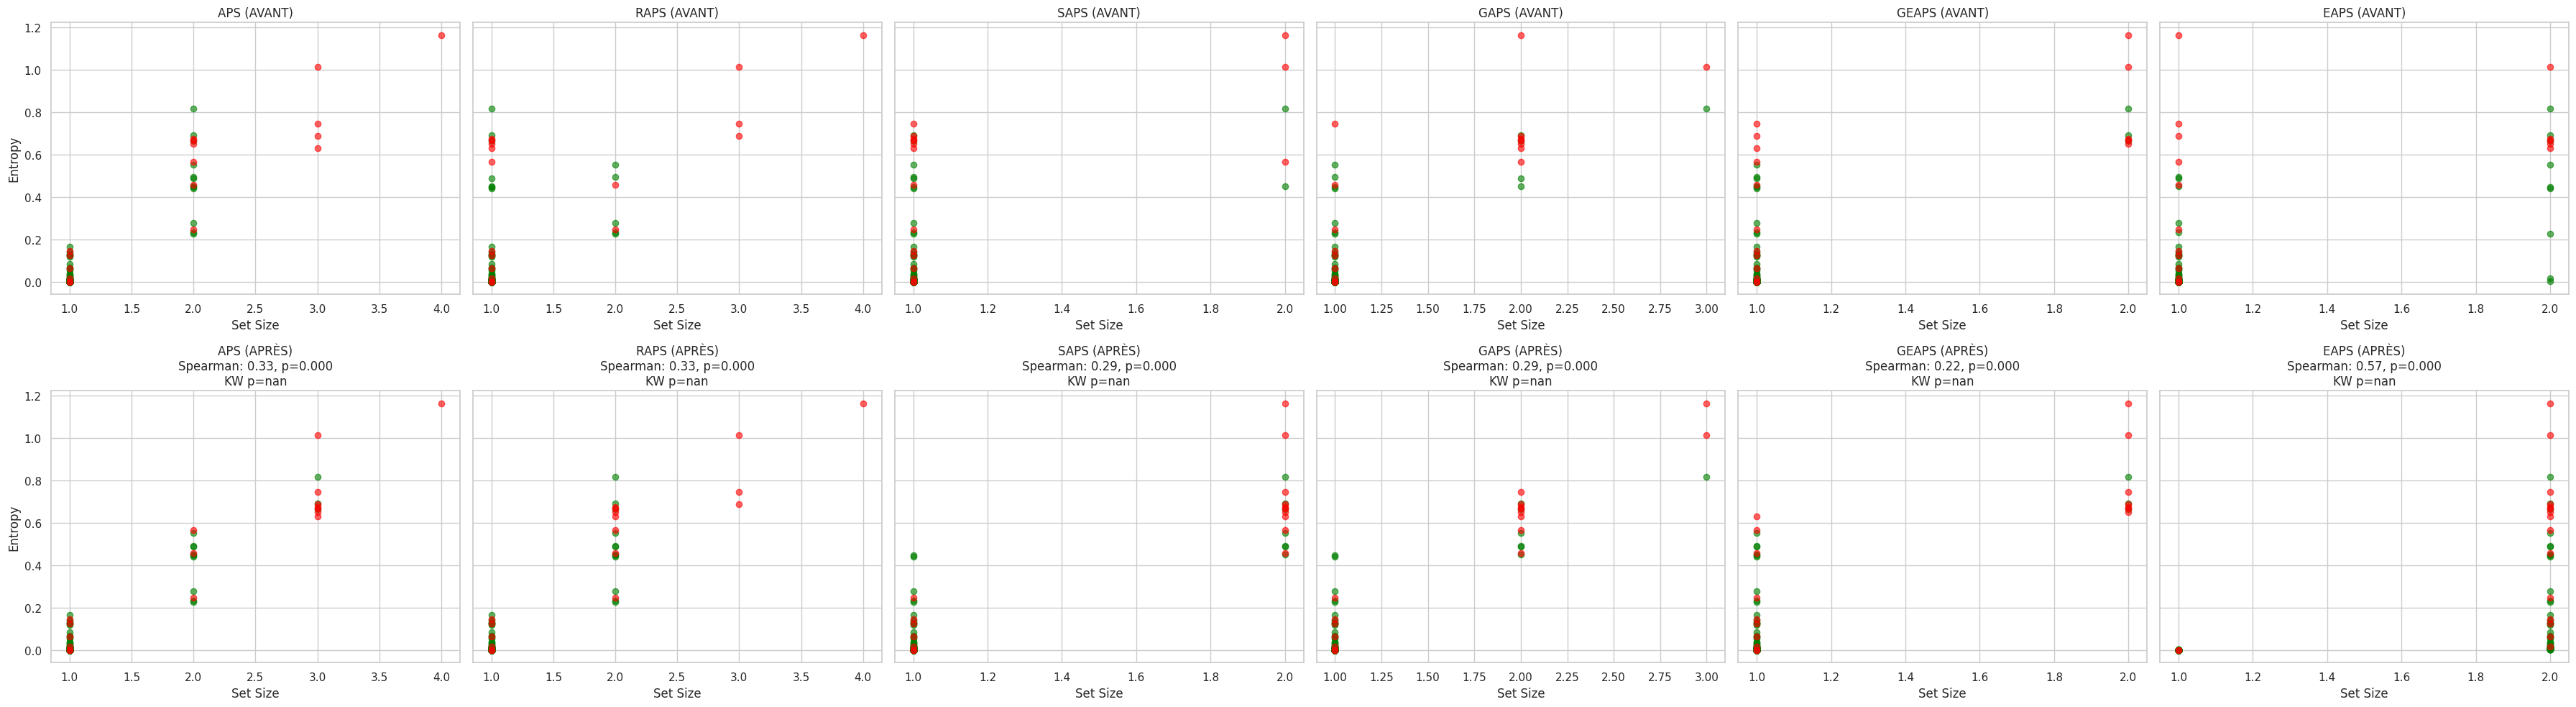

In [37]:
print(f" <======================MCDropout approach======================>")
results_scatter_mcd_ =  analyze_entropy_vs_set_size_all_methods(
    predictor_dict,
    test_probs=results_mcd['y_probs'],
    y_test=results_mcd['y_labels'],
    entropies=results_mcd['entropy']
)

 <======================Deep Ensemble approach======================>


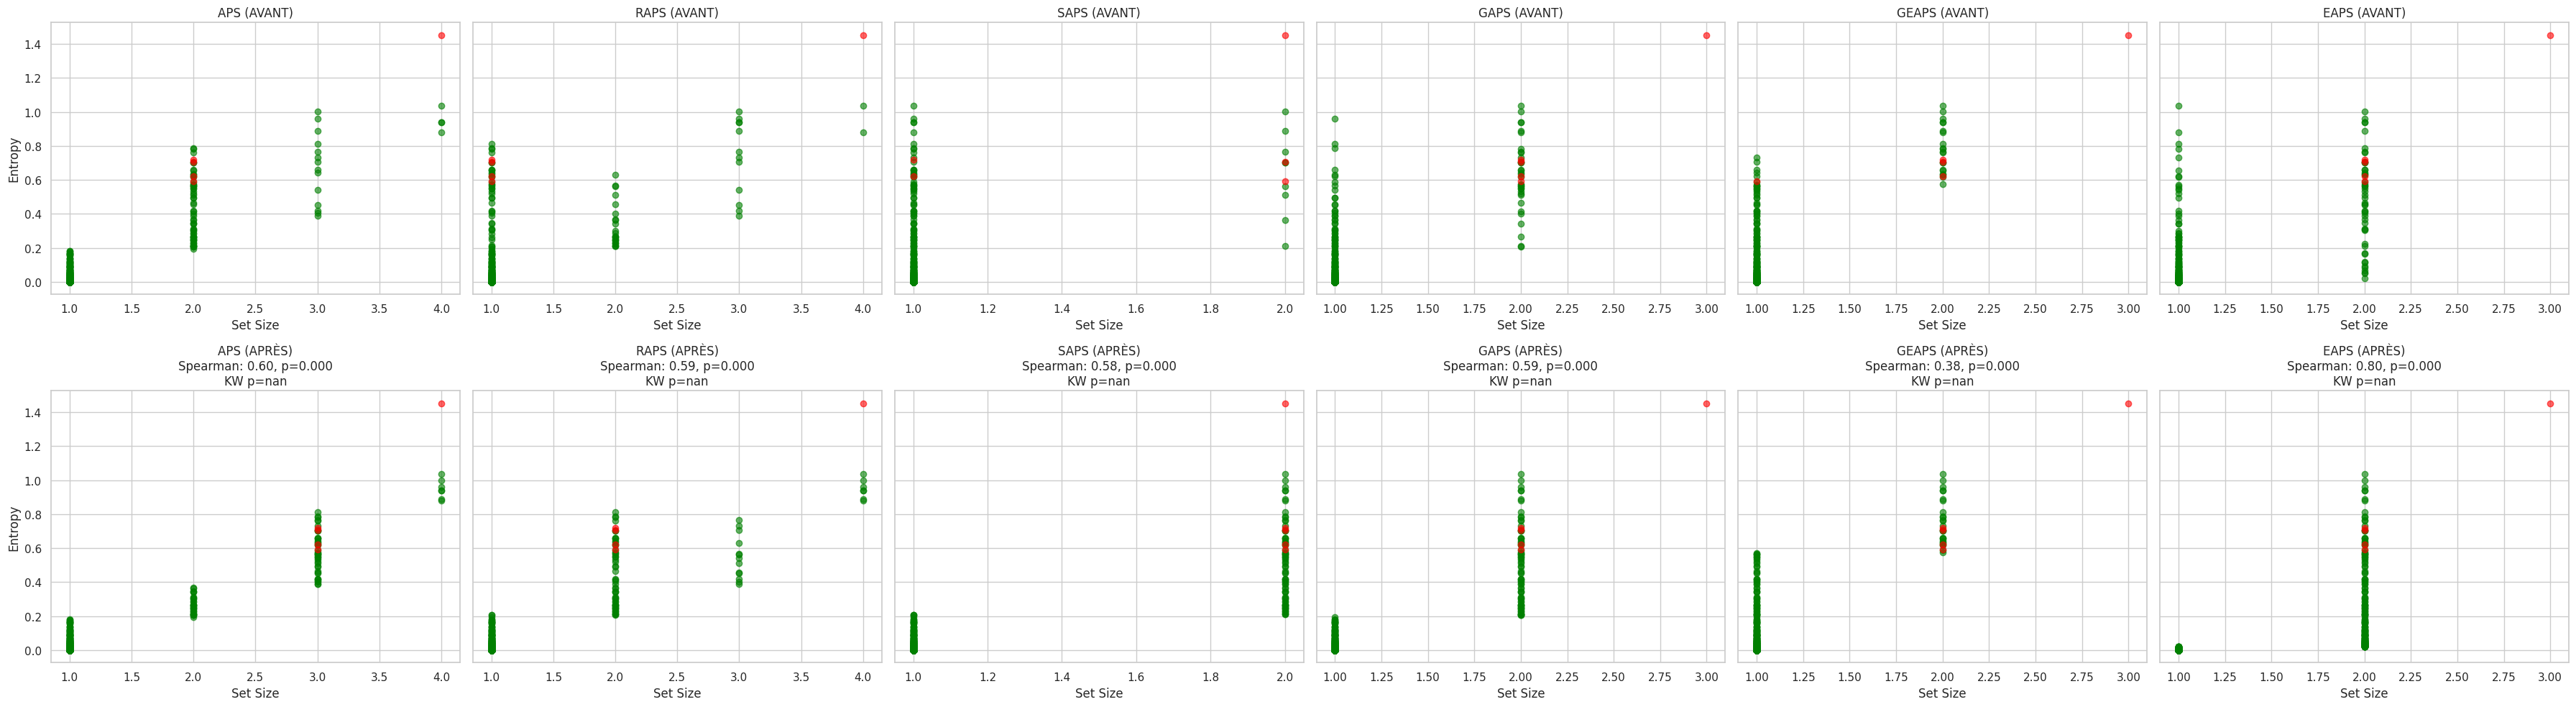

In [38]:
print(f" <======================Deep Ensemble approach======================>")
results_scatter_de_ =  analyze_entropy_vs_set_size_all_methods(
    predictor_dict,
    test_probs=results_de['y_probs'],
    y_test=results_de['y_trues'],
    entropies=results_de['entropy']
)

**06 ODD Detection**

In [ ]:
from src.ood.ood_detection import create_ood_dataset

ood_dataset_dir = "../data/ood_dataset_sipakmed"
image_urls = [
    "https://cdn.pixabay.com/photo/2024/02/24/17/37/lemons-8594421_1280.jpg",
    "https://cdn.pixabay.com/photo/2022/04/05/17/06/butterfly-7114037_640.jpg",
    "https://cdn.pixabay.com/photo/2025/03/21/21/22/roche-9485693_640.jpg",
    "https://cdn.pixabay.com/photo/2021/12/04/20/59/animal-6845972_1280.jpg",
    "https://cdn.pixabay.com/photo/2025/02/25/04/25/desert-9429492_640.jpg"
]

create_ood_dataset(image_urls, ood_dataset_dir)

In [ ]:
from src.ood.ood_detection  import evaluate_ood_entropy_all


id_dir = "/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/data/in_data_sipakmed"
ood_dir = ood_dataset_dir
evaluate_ood_entropy_all(
    models_dict={
        "single": single_net.model,
        "mc_dropout": mcdropout.model,
        "deep_ensemble": deepensemble.model,
    },
    id_dir=id_dir,
    ood_dir=ood_dir,
    device=DEVICE,
    num_passes=5
)


**7.0 Explanability**

In [ ]:
from src.explainability.methods import get_image_and_cam, show_all_gradcams
from src.ood.ood_detection import load_image_tensor

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
image_tensor = load_image_tensor("/kaggle/input/in-distribution-data/dyskeratotic.jpg")
cams = {
    "Single": get_image_and_cam(single_net.model, image_tensor, DEVICE, approach="single"),
    "MC Dropout": get_image_and_cam(mcdropout.model, image_tensor, DEVICE, approach="mc_dropout"),
    "Deep Ensemble": get_image_and_cam(deepensemble.models, image_tensor, DEVICE, approach="deep_ensemble")
}

show_all_gradcams(image_tensor, cams)